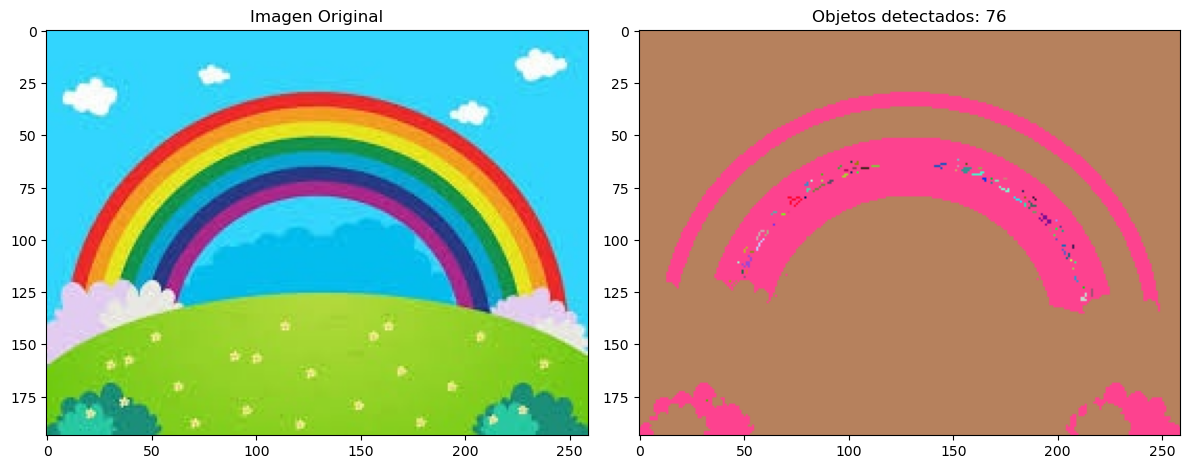

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_y_colorear(imagen):
    gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    _, binarizado = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    etiquetas = measure.label(binarizado, connectivity=2)
    num_objetos = np.max(etiquetas)
    
    colores = np.random.randint(0, 255, size=(num_objetos + 1, 3), dtype=np.uint8)
    color_etiquetas = colores[etiquetas]
    
    return num_objetos, color_etiquetas


imagen = cv2.imread('image.png')

cantidad, colorizado = contar_y_colorear(imagen)

plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(122)
plt.imshow(colorizado)
plt.title(f'Objetos detectados: {cantidad}')

plt.tight_layout()
plt.show()
